# Loading modules 

In [1]:
import torch
from torch import nn 

torch.__version__

'2.10.0+cu130'

overview:
Find a dataset, turn the dataset into numbers, build a model (or find an existing model) to find patterns in those numbers that can be used for prediction.



In [2]:
# testing if torch library works 
tensor1 = torch.tensor([1,2,3])
tensor2 = torch.tensor([3,4,5])

print("hi these tensors work", tensor1, tensor2)

hi these tensors work tensor([1, 2, 3]) tensor([3, 4, 5])


In [3]:
# device agnostic code check 

device = "cuda" if torch.cuda.is_available() else "cpu"
device 

'cuda'

get data Machine learning is an iterative process, start small, get something working and increase when necessary.
Food101 dataset 
Food101 is popular computer vision benchmark as it contains 1000 images of 101 different kinds of foods, totaling 101,000 images (75,750 train and 25,250 test).

we're not using it but we can in the future. we'll be using pngs that we have.

# downloading data

In [4]:
# load images 
import requests # this will call github and downlaod zip folder (good practice to do this )
import zipfile
from pathlib import Path

# Setup path to data folder
# data_path = Path("data/")
# image_path = data_path / "pizza_steak_sushi"

image_path = Path("data/")


print(image_path)

# we don't need this bottom portion since we have our data organized in folders

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
# else:
#     print(f"Did not find {image_path} directory, creating one...")
#     image_path.mkdir(parents=True, exist_ok=True)
    
#     # Download pizza, steak, sushi data
#     with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
#         request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
#         print("Downloading pizza, steak, sushi data...")
#         f.write(request.content)

#     # Unzip pizza, steak, sushi data
#     with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
#         print("Unzipping pizza, steak, sushi data...") 
#         zip_ref.extractall(image_path)


data
data directory exists.


# Data preparation

In [5]:
# counting the directories 

import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


walk_through_dir(image_path)

There are 1 directories and 0 images in 'data'.
There are 4 directories and 0 images in 'data/train'.
There are 0 directories and 2 images in 'data/train/dirt_01'.
There are 0 directories and 2 images in 'data/train/low_tide_rocks_01'.
There are 0 directories and 2 images in 'data/train/muddy_tracks_01'.
There are 0 directories and 2 images in 'data/train/rocky_trail_01'.


In [6]:
# map the training and the test 

train_path = image_path / "train"
print(train_path)
walk_through_dir(train_path)

data/train
There are 4 directories and 0 images in 'data/train'.
There are 0 directories and 2 images in 'data/train/dirt_01'.
There are 0 directories and 2 images in 'data/train/low_tide_rocks_01'.
There are 0 directories and 2 images in 'data/train/muddy_tracks_01'.
There are 0 directories and 2 images in 'data/train/rocky_trail_01'.


## visualize the image 

Random image path: data/train/dirt_01/roughness.png
Image class: dirt_01
Image height: 1024
Image width: 1024


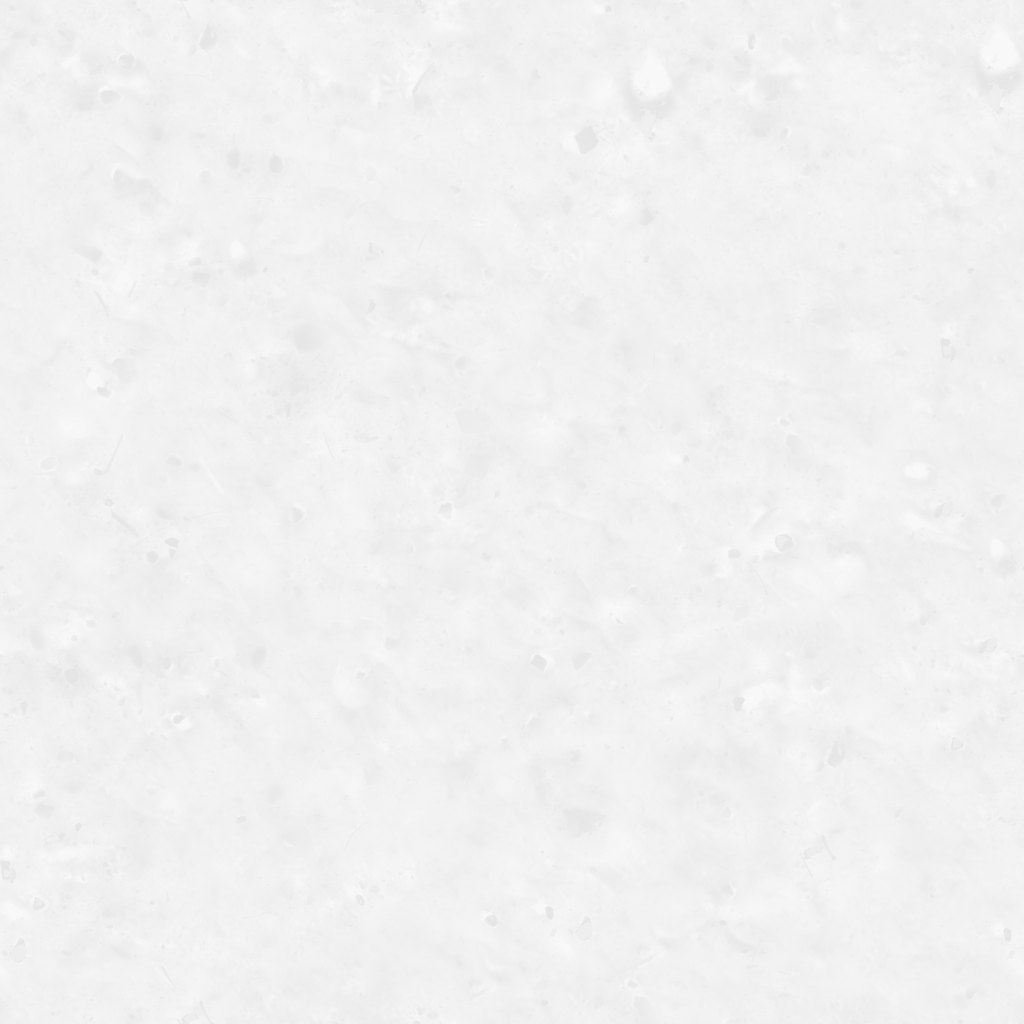

In [7]:
# visualize the image 

import random
from PIL import Image 


random.seed(42) 

list_image_paths = list(train_path.glob("*/*.png"))

# for path in list_image_paths:
#     print(path) 

# print(list_image_paths)

random_image_path = random.choice(list_image_paths)
image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img


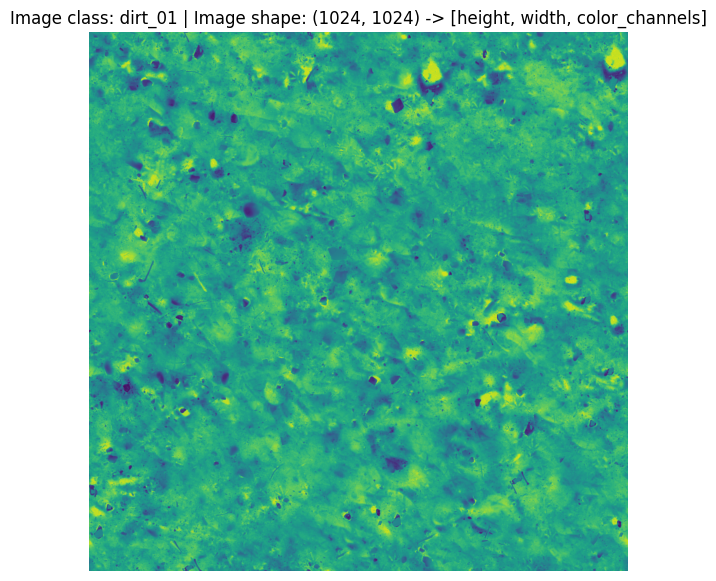

In [8]:
# matplotlib version
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

# dataloader and dataset setup

In [9]:
import torch 
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [10]:
# transform the images into tensor (list of numbers)

# step of transformation
# Write transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(256, 256)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0 
])

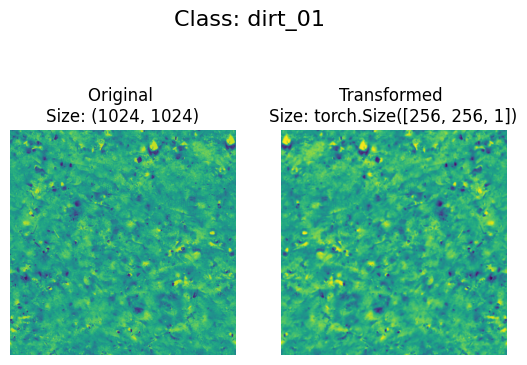

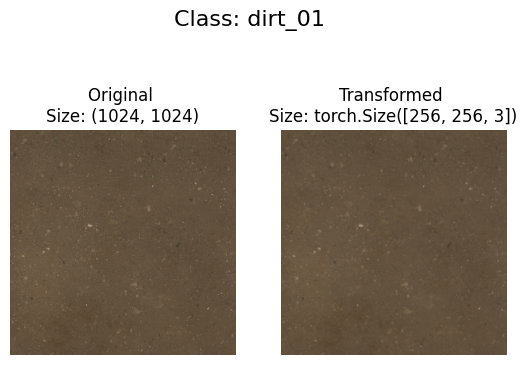

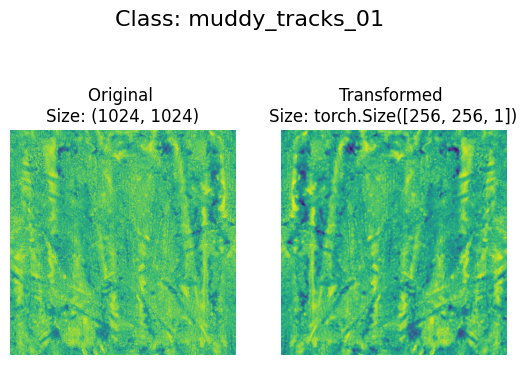

In [11]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f) 
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib 
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0) 
            ax[1].imshow(transformed_image) 
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(list_image_paths, 
                        transform=data_transform, 
                        n=3)

In [12]:
# test 

# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_path, # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

# test_data = datasets.ImageFolder(root=test_dir, 
#                                  transform=data_transform)

print(f"Train data:\n{train_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 8
    Root location: data/train
    StandardTransform
Transform: Compose(
               Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [13]:
# Get class names as a list
class_names = train_data.classes
class_names

['dirt_01', 'low_tide_rocks_01', 'muddy_tracks_01', 'rocky_trail_01']

In [14]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'dirt_01': 0,
 'low_tide_rocks_01': 1,
 'muddy_tracks_01': 2,
 'rocky_trail_01': 3}

In [15]:
# Check the 
#   train_data[0][1]
# , len(test_data)

In [16]:
img, label = train_data[0][0], train_data[0][1]


print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.3922, 0.3765, 0.3804,  ..., 0.3804, 0.3882, 0.3843],
         [0.3804, 0.3843, 0.3882,  ..., 0.3765, 0.3922, 0.3961],
         [0.3882, 0.3765, 0.3373,  ..., 0.3765, 0.3686, 0.3686],
         ...,
         [0.3843, 0.3961, 0.3922,  ..., 0.3843, 0.3843, 0.3922],
         [0.3843, 0.3843, 0.3843,  ..., 0.3843, 0.3882, 0.3961],
         [0.3961, 0.3765, 0.3804,  ..., 0.4039, 0.3843, 0.3961]],

        [[0.3216, 0.3137, 0.3176,  ..., 0.3137, 0.3216, 0.3216],
         [0.3176, 0.3176, 0.3294,  ..., 0.3098, 0.3255, 0.3294],
         [0.3176, 0.3137, 0.2863,  ..., 0.3098, 0.3059, 0.3059],
         ...,
         [0.3137, 0.3255, 0.3216,  ..., 0.3176, 0.3176, 0.3255],
         [0.3176, 0.3176, 0.3176,  ..., 0.3176, 0.3216, 0.3255],
         [0.3255, 0.3137, 0.3176,  ..., 0.3294, 0.3176, 0.3216]],

        [[0.2431, 0.2392, 0.2431,  ..., 0.2353, 0.2431, 0.2431],
         [0.2431, 0.2431, 0.2549,  ..., 0.2353, 0.2471, 0.2510],
         [0.2431, 0.2392, 0.2235,  ..., 0.23

Original shape: torch.Size([3, 256, 256]) -> [color_channels, height, width]
Image permute shape: torch.Size([256, 256, 3]) -> [height, width, color_channels]


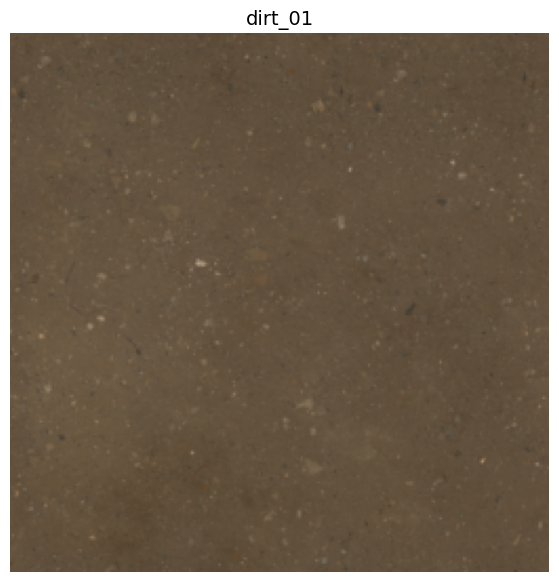

In [17]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

In [18]:
# data loader 
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=1, # how many samples per batch?
                              num_workers=1, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) # shuffle the data?

# test_dataloader = DataLoader(dataset=test_data, 
#                              batch_size=1, 
#                              num_workers=1, 
#                              shuffle=False) # don't usually need to shuffle testing data

train_dataloader
# , test_dataloader

In [19]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 256, 256]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


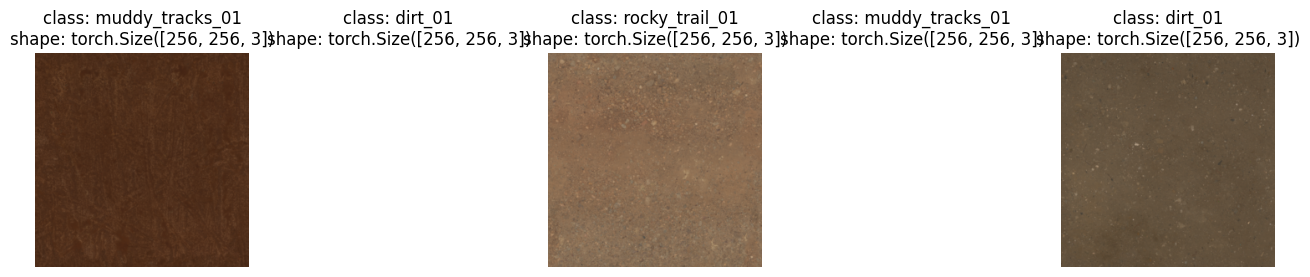

In [20]:
    # 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: list[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    
    # 2. Adjust display if n too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")
    
    # 3. Set random seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples 
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)


# Display random images from ImageFolder created Dataset
display_random_images(train_data, 
                      n=5, 
                      classes=class_names,
                      seed=None)

Number of texture pairs: 4
Albedo shape: torch.Size([3, 256, 256])
Roughness shape: torch.Size([1, 256, 256])


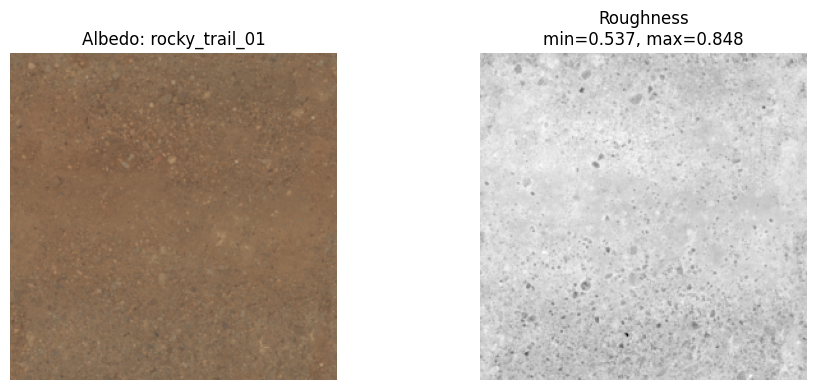

In [21]:
from texture_dataset import PairedTextureDataset, show_texture_pair
from torch.utils.data import DataLoader

paired_train_data = PairedTextureDataset(
    root_dir=train_path,
    image_size=(256, 256),
    random_horizontal_flip=True,
)

print(f"Number of texture pairs: {len(paired_train_data)}")
albedo, roughness = paired_train_data[0]
print(f"Albedo shape: {albedo.shape}")
print(f"Roughness shape: {roughness.shape}")

show_texture_pair(paired_train_data, index=3)

In [22]:
paired_train_dataloader = DataLoader(
    paired_train_data,
    batch_size=2,
    shuffle=True,
    num_workers=0,
)

albedo_batch, roughness_batch = next(iter(paired_train_dataloader))
print(f"Albedo batch shape: {albedo_batch.shape}")
print(f"Roughness batch shape: {roughness_batch.shape}")

Albedo batch shape: torch.Size([2, 3, 256, 256])
Roughness batch shape: torch.Size([2, 1, 256, 256])


Sample: dirt_01

Raw files
  albedo    mode=RGB dtype=uint8 shape=(1024, 1024, 3) min=12 max=212
  roughness mode=I;16 dtype=uint16 shape=(1024, 1024) min=58512 max=64262

Dataset tensors
  albedo    shape=(3, 256, 256) dtype=torch.float32 min=0.172549 max=0.705882
  roughness shape=(1, 256, 256) dtype=torch.float32 min=0.897933 max=0.974100


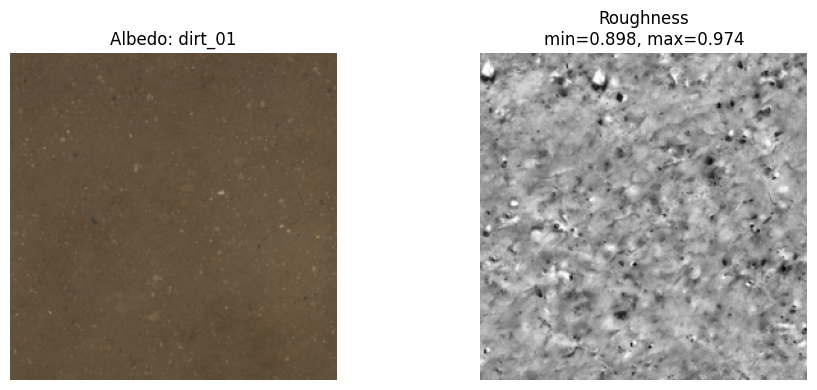

In [23]:
import importlib
import texture_dataset
importlib.reload(texture_dataset)

from texture_dataset import PairedTextureDataset, show_texture_pair, debug_texture_pair

paired_train_data = PairedTextureDataset(
    root_dir=train_path,
    image_size=(256, 256),
    random_horizontal_flip=True,
)

debug_texture_pair(paired_train_data, index=0)
show_texture_pair(paired_train_data, index=0)


Epoch 1/20 - train_mae=0.379092, rmse=0.348557, cosine_similarity=0.998314
Epoch 2/20 - train_mae=0.323790, rmse=0.337407, cosine_similarity=0.998327
Epoch 3/20 - train_mae=0.270818, rmse=0.325298, cosine_similarity=0.998353
Epoch 4/20 - train_mae=0.250326, rmse=0.309379, cosine_similarity=0.998399
Epoch 5/20 - train_mae=0.230494, rmse=0.300513, cosine_similarity=0.998298
Epoch 6/20 - train_mae=0.219871, rmse=0.301675, cosine_similarity=0.997665
Epoch 7/20 - train_mae=0.213815, rmse=0.304803, cosine_similarity=0.996659
Epoch 8/20 - train_mae=0.210210, rmse=0.303747, cosine_similarity=0.995868
Epoch 9/20 - train_mae=0.184732, rmse=0.298556, cosine_similarity=0.995665
Epoch 10/20 - train_mae=0.202694, rmse=0.291214, cosine_similarity=0.995683
Epoch 11/20 - train_mae=0.195985, rmse=0.286231, cosine_similarity=0.995625
Epoch 12/20 - train_mae=0.161362, rmse=0.280245, cosine_similarity=0.995419
Epoch 13/20 - train_mae=0.184763, rmse=0.271739, cosine_similarity=0.994971
Epoch 14/20 - train_m

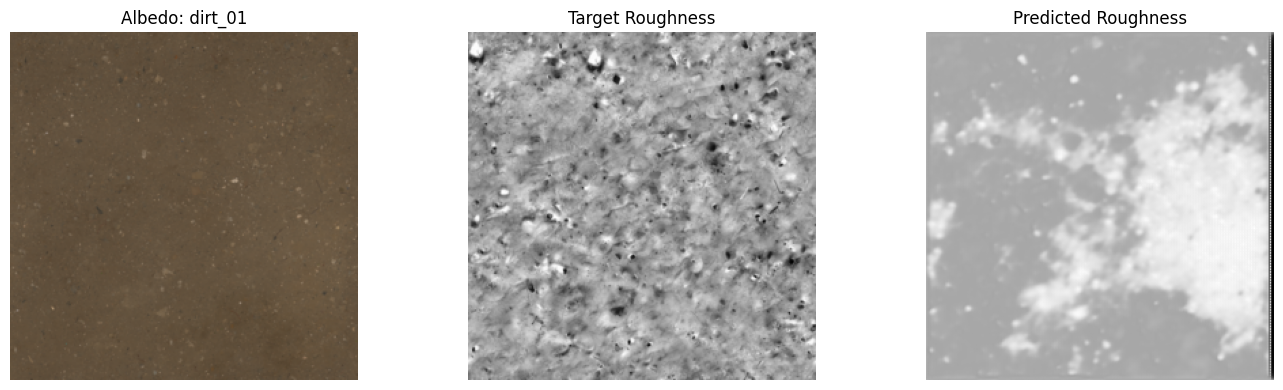

In [24]:
from torch.utils.data import DataLoader
from texture_model import RoughnessUNet, fit_model, evaluate_model, show_prediction

paired_train_dataloader = DataLoader(
    paired_train_data,
    batch_size=2,
    shuffle=True,
    num_workers=0,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = RoughnessUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
history = fit_model(model, paired_train_dataloader, optimizer, device, epochs=epochs)

for row in history:
    print(
        f"Epoch {row['epoch']}/{epochs} - "
        f"train_mae={row['train_mae']:.6f}, "
        f"rmse={row['rmse']:.6f}, "
        f"cosine_similarity={row['cosine_similarity']:.6f}"
    )

final_metrics = evaluate_model(model, paired_train_dataloader, device)
print("\nFinal metrics:")
for name, value in final_metrics.items():
    print(f"{name}: {value:.6f}")

show_prediction(model, paired_train_data, index=0, device=device)

In [25]:
import importlib
import texture_model
importlib.reload(texture_model)

from texture_model import RoughnessAutoencoder

ablation_results = {}

ablation_models = {
    "unet_skip_connections": RoughnessUNet,
    "autoencoder_no_skips": RoughnessAutoencoder,
}

epochs = 20
for name, model_class in ablation_models.items():
    print(f"\nRunning ablation: {name}")
    model = model_class().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = fit_model(model, paired_train_dataloader, optimizer, device, epochs=epochs)
    ablation_results[name] = history[-1]
    print(ablation_results[name])

print("\nAblation summary:")
for name, metrics in ablation_results.items():
    print(
        f"{name}: "
        f"train_mae={metrics['train_mae']:.6f}, "
        f"mae={metrics['mae']:.6f}, "
        f"rmse={metrics['rmse']:.6f}, "
        f"cosine_similarity={metrics['cosine_similarity']:.6f}"
    )


Running ablation: unet_skip_connections
{'mae': 0.20846834033727646, 'mse': 0.0649521816521883, 'rmse': 0.2548571789300594, 'cosine_similarity': 0.9930351972579956, 'train_mae': 0.1747121438384056, 'epoch': 20}

Running ablation: autoencoder_no_skips
{'mae': 0.13209137320518494, 'mse': 0.028172990307211876, 'rmse': 0.167848116781845, 'cosine_similarity': 0.9978055059909821, 'train_mae': 0.09461170434951782, 'epoch': 20}

Ablation summary:
unet_skip_connections: train_mae=0.174712, mae=0.208468, rmse=0.254857, cosine_similarity=0.993035
autoencoder_no_skips: train_mae=0.094612, mae=0.132091, rmse=0.167848, cosine_similarity=0.997806
